<a href="https://colab.research.google.com/github/muhammadzohaib09001-dotcom/FACIAL_EMOTION_RECOGNATION_USING_CNN_TRANSFER_LEARNING/blob/main/FacialEmotionRecognition_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PAM2002 Data Science Project
##Facial Emotion Recognition Using CNN and Transfer Learning
##Student: Muhammad Zohaib Khan
##Module: 7PAM2002 Data Science Project
##Semester: A 2025/2026

---

## Research Questions
1. How do different data preprocessing and augmentation methods affect the performance of facial emotion recognition models?
2. How do different CNN architectures compare in extracting facial features for emotion recognition?
3. How does the performance of CNN-based models compare with that of Transfer models for facial emotion recognition from images?
4. How do CNN and Transfer models differ in classification performance and error patterns when evaluated using standard metrics?


## Table of Contents
1. [Environment Setup & Imports](#1)
2. [Dataset Loading](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Data Preprocessing & Class Imbalance Handling](#4)
5. [Data Augmentation & DataLoaders](#5)
6. [Model 1: Simple Custom CNN Model](#6)
7. [Model 2: Hypermodel CNN Fine Tunned](#7)
8. [Model 3: Transfer Learning Model](#8)
9. [Model 4: Fine Tunned Transfer Learning Model](#8)



# 1. Importing Libraries



In [1]:
!pip install keras-tuner

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import tensorflow as tf
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 2. Dataset Loading

In [4]:
dataset_path = "/content/drive/MyDrive/emotion-recognition-dataset/Dataset/dataset/"

print("Dataset path exists:", os.path.exists(dataset_path))
print("Folders/classes:", os.listdir(dataset_path))

Dataset path exists: True
Folders/classes: ['Sad', 'Neutral', 'Surprise', 'Happy', 'Angry', 'Ahegao']


Setting Image and Batch Side

In [5]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

Loading the dataset using Keras:

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

Found 15454 files belonging to 6 classes.
Using 10818 files for training.
Found 15454 files belonging to 6 classes.
Using 4636 files for validation.


Now spliting the temporary 30% into validation and test sets.

In [7]:
val_batches = tf.data.experimental.cardinality(temp_ds)
test_ds = temp_ds.take(val_batches // 2)
val_ds = temp_ds.skip(val_batches // 2)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Class names: ['Ahegao', 'Angry', 'Happy', 'Neutral', 'Sad', 'Surprise']
Number of classes: 6


# 3. Exploratory Data Analysis

**Display Sample Images**

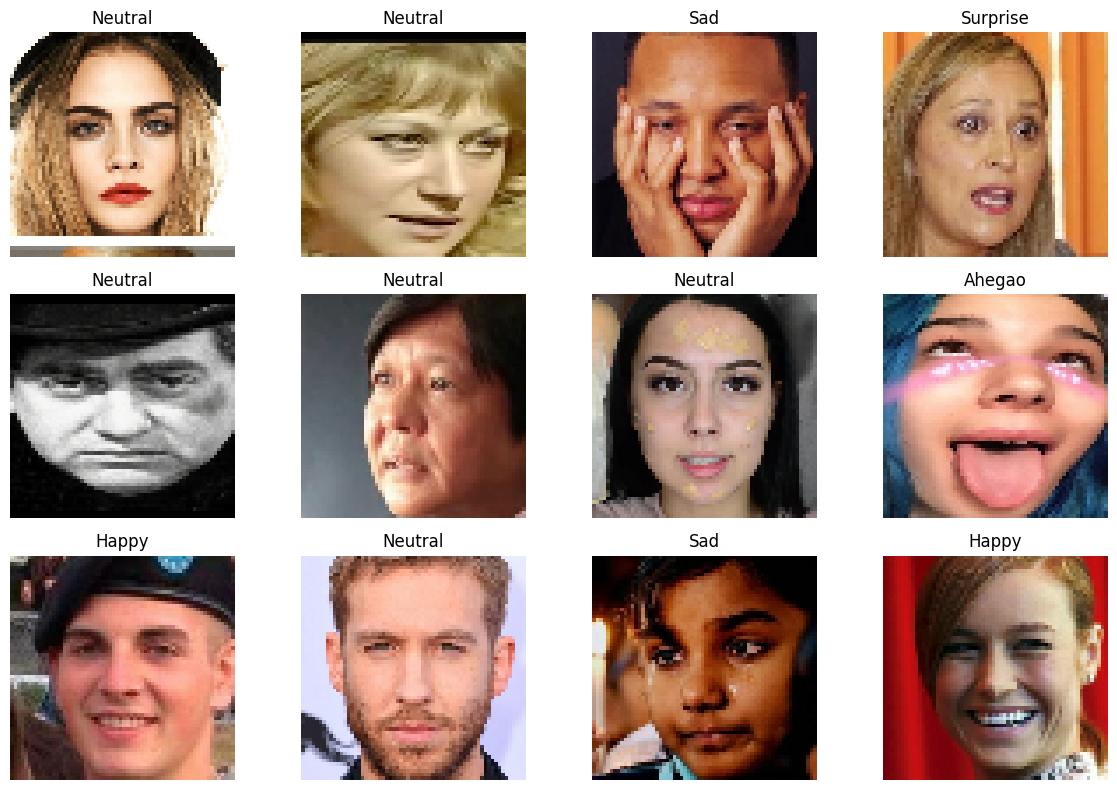

In [8]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(min(12, len(images))):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

**Class Distribution**

In [9]:
class_counts = {}

for class_name in class_names:
    class_dir = os.path.join(dataset_path, class_name)
    class_counts[class_name] = len([
        file for file in os.listdir(class_dir)
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ])

print("Class distribution:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Class distribution:
Ahegao: 1206
Angry: 1313
Happy: 3740
Neutral: 4027
Sad: 3934
Surprise: 1234


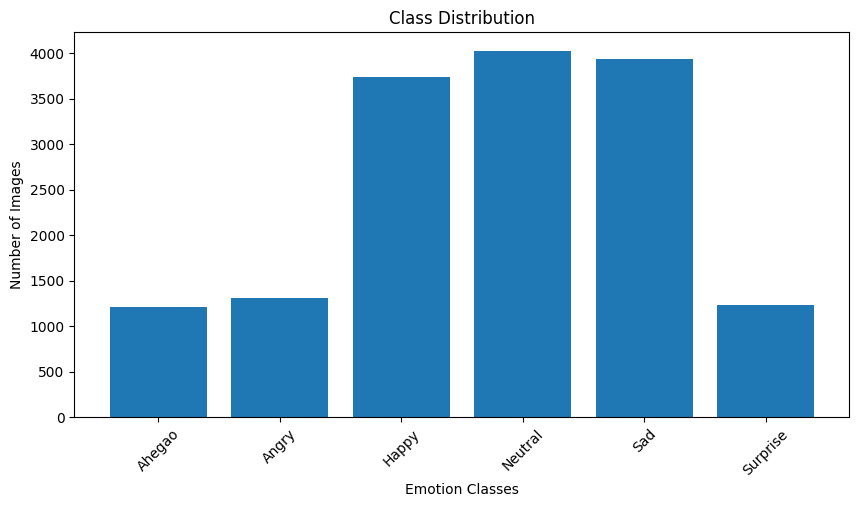

In [10]:
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Emotion Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

# 4. Data Preprocessing & Class Imbalance Handling

Images loaded by image_dataset_from_directory are originally in the range 0 to 255. We will normalize them to 0 to 1 inside the model using a Rescaling layer.
 For imbalance handling, we will calculate class weights.

In [11]:
all_labels = []

for class_index, class_name in enumerate(class_names):
    class_dir = os.path.join(dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_dir)
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]

    all_labels.extend([class_index] * len(image_files))

all_labels = np.array(all_labels)

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(all_labels),
    y=all_labels
)

class_weights = {
    i: class_weights_values[i]
    for i in range(len(class_weights_values))
}

print("Class weights:")
print(class_weights)

Class weights:
{0: np.float64(2.1357103372028745), 1: np.float64(1.9616653973089617), 2: np.float64(0.6886809269162211), 3: np.float64(0.6395993709130039), 4: np.float64(0.6547195390611761), 5: np.float64(2.0872501350621286)}


These weights will be passed to model.fit() later:

In [12]:
class_weight=class_weights

# 5. Data Augmentation & DataLoaders

In [13]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1)
], name="data_augmentation")

**Improve Loading Performance**

In [14]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 6. Defining Simple Custom CNN Model

In [15]:
model = keras.Sequential([
    layers.Input(shape=(64, 64, 3)),

    layers.Rescaling(1./255),

    data_augmentation,

    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])

**Model Summery**

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 548,774 (2.09 MB)

 Trainable params: 548,774 (2.09 MB)

 Non-trainable params: 0 (0.00 B)

**Compile the Model**

In [17]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the Simple CNN Model

In [18]:
EPOCHS = 35

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights
)

Epoch 1/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 63s 28ms/step - accuracy: 0.2168 - loss: 1.7312 - val_accuracy: 0.2384 - val_loss: 1.6819
Epoch 2/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2940 - loss: 1.5857 - val_accuracy: 0.3122 - val_loss: 1.5827
Epoch 3/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3212 - loss: 1.5123 - val_accuracy: 0.3062 - val_loss: 1.5710
Epoch 4/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3474 - loss: 1.4615 - val_accuracy: 0.3907 - val_loss: 1.4346
Epoch 5/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3564 - loss: 1.4218 - val_accuracy: 0.3739 - val_loss: 1.4563
Epoch 6/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3649 - loss: 1.3881 - val_accuracy: 0.3907 - val_loss: 1.4231
Epoch 7/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3768 - loss: 1.3618 - val_accuracy: 0.3984 - val_loss: 1.4129
Epoch 8/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3845 - loss: 1.3442 - val_accuracy: 

**Plot Training and Validation Results**

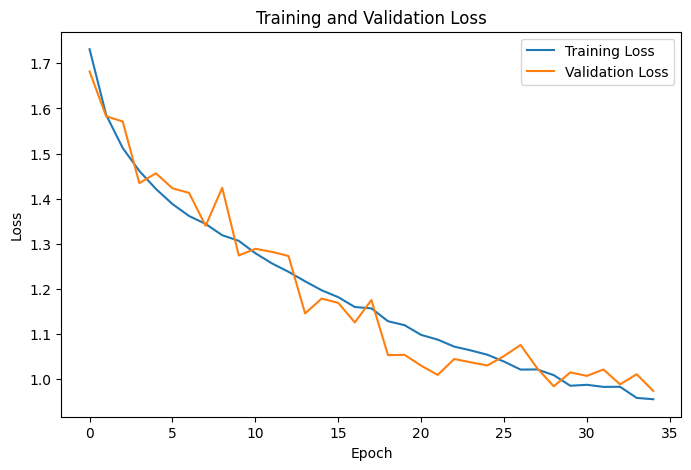

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

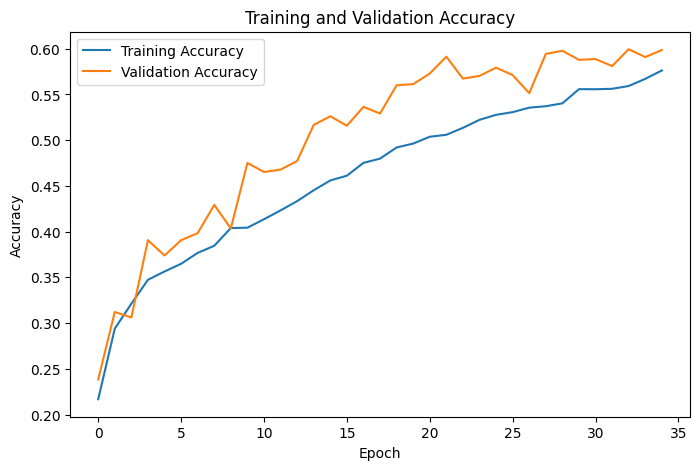

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

# Evaluate on Test Set

In [21]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.6037 - loss: 0.9594
Test Loss: 0.9594
Test Accuracy: 0.6037


**Classification Report and Confusion Matrix**

In [22]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [23]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

      Ahegao       0.87      0.92      0.90       172
       Angry       0.29      0.78      0.42       190
       Happy       0.87      0.69      0.77       502
     Neutral       0.58      0.59      0.59       612
         Sad       0.66      0.42      0.51       623
    Surprise       0.61      0.56      0.58       205

    accuracy                           0.60      2304
   macro avg       0.65      0.66      0.63      2304
weighted avg       0.67      0.60      0.62      2304



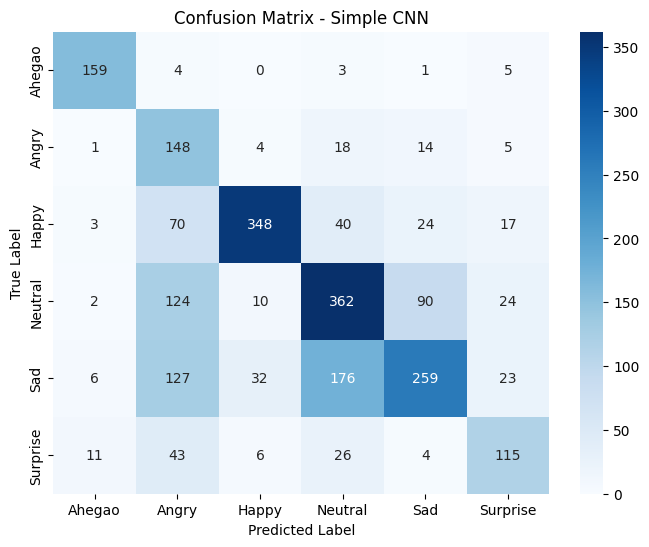

In [24]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Simple CNN")
plt.show()

# Showing Sample Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


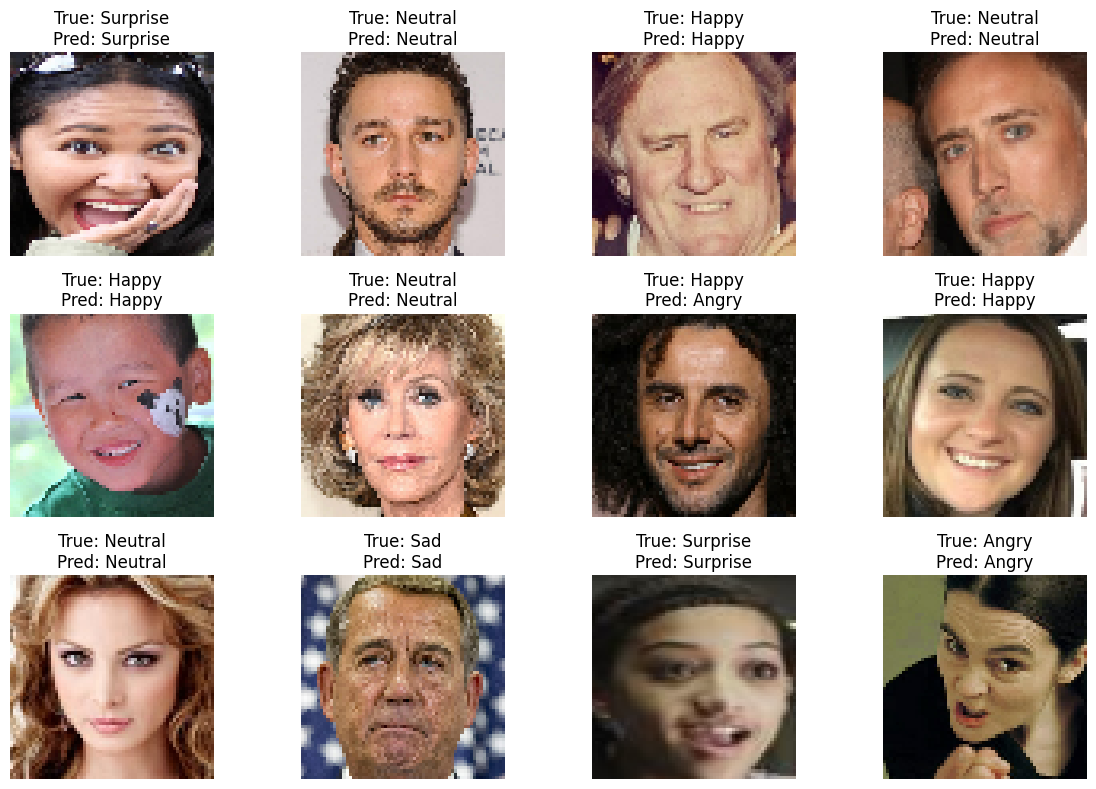

In [25]:
plt.figure(figsize=(12, 8))

for images, labels in test_ds.take(1):
    predictions = model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)

    for i in range(min(12, len(images))):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        true_label = class_names[labels[i]]
        predicted_label = class_names[predicted_classes[i]]

        plt.title(f"True: {true_label}\nPred: {predicted_label}")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
model.save("/content/drive/MyDrive/simple_cnn_emotion_model.keras")

# 7. Defining the Hypermodel
(mean model with hyper parameter tunning)

In [27]:
def build_safe_tuned_cnn(hp):
    model = keras.Sequential([
        layers.Input(shape=(64, 64, 3)),

        # Normalize pixel values
        layers.Rescaling(1./255),

        # Data augmentation
        data_augmentation,

        # Conv Block 1
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Conv Block 2
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Conv Block 3
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Conv Block 4
        layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(
            units=hp.Choice("dense_units", values=[64, 128, 256, 512]),
            activation="relu"
        ),
        layers.BatchNormalization(),

        layers.Dropout(
            rate=hp.Choice("dropout_rate", values=[0.2, 0.3, 0.4, 0.5])
        ),

        layers.Dense(num_classes, activation="softmax")
    ])

    learning_rate = hp.Choice(
        "learning_rate",
        values=[1e-3, 5e-4, 1e-4]
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Create the Tuner

We will use Random Search.
Random Search tests random combinations of hyperparameters. It is simple and effective for a second baseline model.

In [28]:
tuner_safe = kt.RandomSearch(
    hypermodel=build_safe_tuned_cnn,
    objective="val_accuracy",
    max_trials=20,
    executions_per_trial=1,
    directory="/content/tuning_results",
    project_name="safe_tuned_cnn_bn",
    overwrite=True
)

**View Search Space**

In [29]:
tuner_safe.search_space_summary()

Search space summary
Default search space size: 3
dense_units (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256, 512], 'ordered': True}
dropout_rate (Choice)
{'default': 0.2, 'conditions': [], 'values': [0.2, 0.3, 0.4, 0.5], 'ordered': True}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0005, 0.0001], 'ordered': True}


# Run Hyperparameter Tuning

In [30]:
early_stopping_safe = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [31]:
tuner_safe.search(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping_safe]
)
# This will train multiple CNN models and select the best one.

Trial 20 Complete [00h 00m 37s]
val_accuracy: 0.40737563371658325

Best val_accuracy So Far: 0.7439965605735779
Total elapsed time: 00h 32m 13s


# Show Best Hyperparameters

In [32]:
best_hps_safe = tuner_safe.get_best_hyperparameters(num_trials=1)[0]

print("Best Hyperparameters:")
print("Dense Units:", best_hps_safe.get("dense_units"))
print("Dropout Rate:", best_hps_safe.get("dropout_rate"))
print("Learning Rate:", best_hps_safe.get("learning_rate"))

Best Hyperparameters:
Dense Units: 64
Dropout Rate: 0.2
Learning Rate: 0.0005


# Build the Best Model

In [33]:
best_safe_tuned_model = tuner_safe.hypermodel.build(best_hps_safe)

best_safe_tuned_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 1,438,950 (5.49 MB)

 Trainable params: 1,436,902 (5.48 MB)

 Non-trainable params: 2,048 (8.00 KB)

# Train the Best Tuned CNN Model Fully

After finding the best hyperparameters, train the best model again for more epochs.

In [34]:
early_stopping_final_safe = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_safe_tuned = best_safe_tuned_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stopping_final_safe]
)

Epoch 1/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.3403 - loss: 1.6931 - val_accuracy: 0.3229 - val_loss: 1.6444
Epoch 2/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.4677 - loss: 1.3380 - val_accuracy: 0.5167 - val_loss: 1.2107
Epoch 3/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.5053 - loss: 1.2264 - val_accuracy: 0.5515 - val_loss: 1.1437
Epoch 4/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5727 - loss: 1.0715 - val_accuracy: 0.3156 - val_loss: 1.7732
Epoch 5/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.6207 - loss: 0.9665 - val_accuracy: 0.6625 - val_loss: 0.8736
Epoch 6/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.6516 - loss: 0.8758 - val_accuracy: 0.6788 - val_loss: 0.8488
Epoch 7/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.6722 - loss: 0.8180 - val_accuracy: 0.6904 - val_loss: 0.7646
Epoch 8/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.6948 - loss: 0.7732 - val_acc

**Ploting Tuned Model Accuracy and Loss**

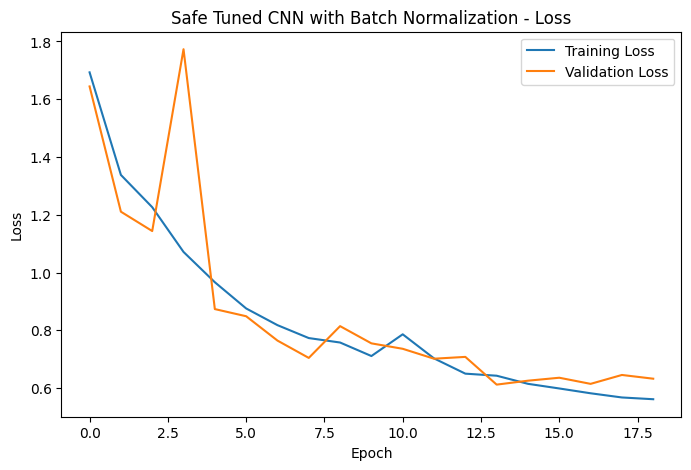

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(history_safe_tuned.history["loss"], label="Training Loss")
plt.plot(history_safe_tuned.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Safe Tuned CNN with Batch Normalization - Loss")
plt.legend()
plt.show()

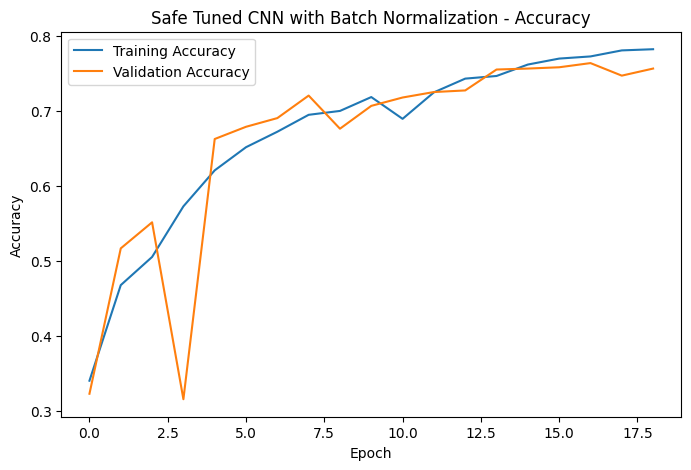

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(history_safe_tuned.history["accuracy"], label="Training Accuracy")
plt.plot(history_safe_tuned.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Safe Tuned CNN with Batch Normalization - Accuracy")
plt.legend()
plt.show()

# Evaluate Tuned CNN on Test Set

In [37]:
test_loss_safe, test_accuracy_safe = best_safe_tuned_model.evaluate(test_ds)

print(f"Safe Tuned CNN Test Loss: {test_loss_safe:.4f}")
print(f"Safe Tuned CNN Test Accuracy: {test_accuracy_safe:.4f}")

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7678 - loss: 0.6165
Safe Tuned CNN Test Loss: 0.6165
Safe Tuned CNN Test Accuracy: 0.7678


# Classification Report for Tuned CNN

In [38]:
y_true_safe = []
y_pred_safe = []

for images, labels in test_ds:
    predictions = best_safe_tuned_model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true_safe.extend(labels.numpy())
    y_pred_safe.extend(predicted_classes)

y_true_safe = np.array(y_true_safe)
y_pred_safe = np.array(y_pred_safe)

In [39]:
print(classification_report(
    y_true_safe,
    y_pred_safe,
    target_names=class_names
))

              precision    recall  f1-score   support

      Ahegao       0.93      0.91      0.92       172
       Angry       0.67      0.73      0.70       190
       Happy       0.92      0.89      0.91       502
     Neutral       0.70      0.71      0.71       612
         Sad       0.70      0.74      0.72       623
    Surprise       0.79      0.63      0.70       205

    accuracy                           0.77      2304
   macro avg       0.79      0.77      0.78      2304
weighted avg       0.77      0.77      0.77      2304



# Confusion Matrix for Tuned CNN

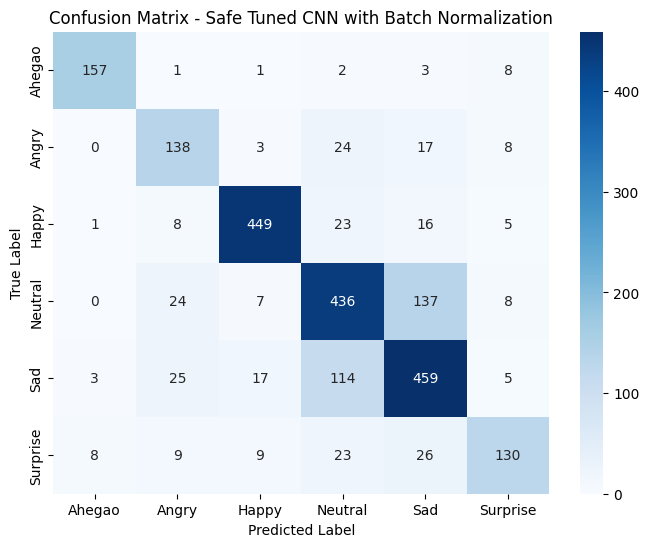

In [40]:
cm_safe = confusion_matrix(y_true_safe, y_pred_safe)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_safe,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Safe Tuned CNN with Batch Normalization")
plt.show()

# Compare Simple CNN vs Tuned CNN

In [41]:
print("Simple CNN Test Accuracy:", test_accuracy)
print("Safe Tuned CNN Test Accuracy:", test_accuracy_safe)

Simple CNN Test Accuracy: 0.6037326455116272
Safe Tuned CNN Test Accuracy: 0.7677951455116272


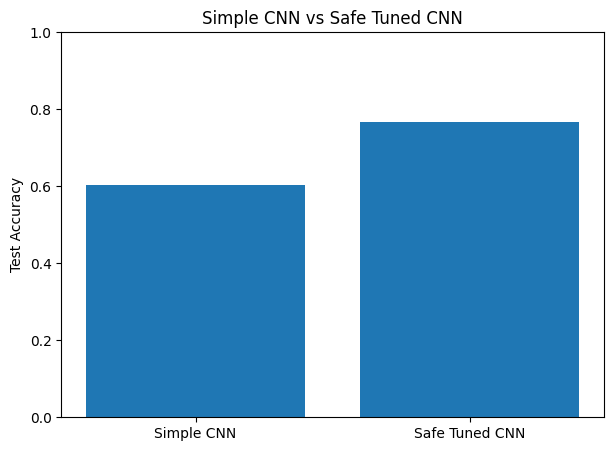

In [42]:
model_names = ["Simple CNN", "Safe Tuned CNN"]
model_accuracies = [test_accuracy, test_accuracy_safe]

plt.figure(figsize=(7, 5))
plt.bar(model_names, model_accuracies)
plt.ylabel("Test Accuracy")
plt.title("Simple CNN vs Safe Tuned CNN")
plt.ylim(0, 1)
plt.show()

# Save the Tuned CNN Model

In [43]:
best_safe_tuned_model.save("/content/drive/MyDrive/safe_tuned_cnn_bn_model.keras")

# 8. Appling Transfer Model

**Reloading the Dataset with 128x128 Image Size**

In [114]:
dataset_path = "/content/drive/MyDrive/emotion-recognition-dataset/Dataset/dataset"

IMG_SIZE_tl = (128, 128)
BATCH_SIZE = 32
SEED = 42

In [115]:
train_ds_tl = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE_tl,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

temp_ds_tl = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE_tl,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

Found 15454 files belonging to 6 classes.
Using 10818 files for training.
Found 15454 files belonging to 6 classes.
Using 4636 files for validation.


**Split the 30% validation portion into validation and test:**

In [116]:
val_batches_tl = tf.data.experimental.cardinality(temp_ds_tl)

test_ds_tl = temp_ds_tl.take(val_batches_tl // 2)
val_ds_tl = temp_ds_tl.skip(val_batches_tl // 2)

class_names = train_ds_tl.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Class names: ['Ahegao', 'Angry', 'Happy', 'Neutral', 'Sad', 'Surprise']
Number of classes: 6


# Recalculate Class Weights

Because we loaded a new dataset pipeline, recalculate class weights from the folder structure.

In [117]:
import os

all_labels_tl = []

for class_index, class_name in enumerate(class_names):
    class_dir = os.path.join(dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_dir)
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]

    all_labels_tl.extend([class_index] * len(image_files))

all_labels_tl = np.array(all_labels_tl)

class_weights_values_tl = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(all_labels_tl),
    y=all_labels_tl
)

class_weights_tl = {
    i: class_weights_values_tl[i]
    for i in range(len(class_weights_values_tl))
}

print("Class weights for VGG16:")
print(class_weights_tl)

Class weights for VGG16:
{0: np.float64(2.1357103372028745), 1: np.float64(1.9616653973089617), 2: np.float64(0.6886809269162211), 3: np.float64(0.6395993709130039), 4: np.float64(0.6547195390611761), 5: np.float64(2.0872501350621286)}


**Improve Dataset Loading Speed**

In [118]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds_tl = train_ds_tl.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds_tl = val_ds_tl.cache().prefetch(buffer_size=AUTOTUNE)
test_ds_tl = test_ds_tl.cache().prefetch(buffer_size=AUTOTUNE)

**Data Augmentation for VGG16**

In [119]:
data_augmentation_tl= tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
], name="data_augmentation_vgg16")

# Appling DenseNet121 Model

In [120]:

IMG_SHAPE_tl = (128, 128, 3)
base_model = DenseNet121(
    input_shape=IMG_SHAPE_tl,
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

**Now build the full model:**

In [121]:
inputs = layers.Input(shape=IMG_SHAPE_tl )

x = data_augmentation_tl(inputs)


x = preprocess_input(x)

# Frozen feature extractor
x = base_model (x, training=False)

# Classification head
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

tl_model = models.Model(inputs, outputs)

# Model Summery

In [122]:
tl_model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation_vgg16         │ (None, 128, 128, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_4 (TrueDivide)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_2 (Add)                     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_5 (TrueDivide)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 4, 4, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,335,110 (27.98 MB)

 Trainable params: 296,838 (1.13 MB)

 Non-trainable params: 7,038,272 (26.85 MB)

**Compile the Model**

In [123]:
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

**Train Only the New Classification Head**

In [124]:
early_stopping_tl = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr_tl = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

**Training Transfer Learning Model**

In [125]:
history = tl_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=25,
    callbacks=[early_stopping_tl, reduce_lr_tl]
)

Epoch 1/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 85s 63ms/step - accuracy: 0.4231 - loss: 1.7206 - val_accuracy: 0.5437 - val_loss: 1.1967 - learning_rate: 0.0010
Epoch 2/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.5125 - loss: 1.2661 - val_accuracy: 0.5776 - val_loss: 1.0719 - learning_rate: 0.0010
Epoch 3/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.5471 - loss: 1.1511 - val_accuracy: 0.5939 - val_loss: 1.0289 - learning_rate: 0.0010
Epoch 4/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.5597 - loss: 1.0899 - val_accuracy: 0.6003 - val_loss: 0.9764 - learning_rate: 0.0010
Epoch 5/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.5784 - loss: 1.0624 - val_accuracy: 0.5926 - val_loss: 1.0154 - learning_rate: 0.0010
Epoch 6/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.5832 - loss: 1.0509 - val_accuracy: 0.5999 - val_loss: 0.9912 - learning_rate: 0.0010
Epoch 7/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.5876 - l

**Plot Training Results**

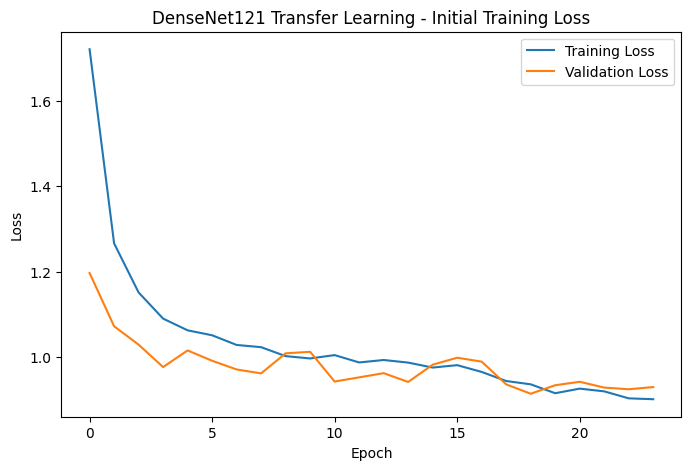

In [126]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet121 Transfer Learning - Initial Training Loss")
plt.legend()
plt.show()

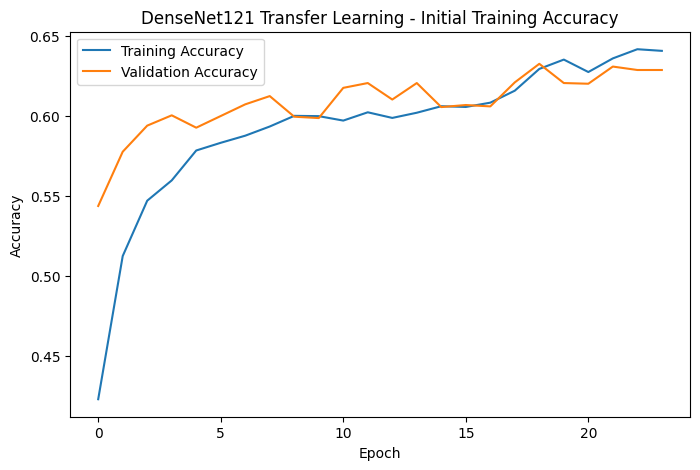

In [127]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DenseNet121 Transfer Learning - Initial Training Accuracy")
plt.legend()
plt.show()

# Result of Transfer Learning Model on Test Set

In [128]:
test_loss_tl, test_accuracy_tl = tl_model.evaluate(test_ds_tl)

print(f"Initial Transfer Learning Test Loss: {test_loss_tl:.4f}")
print(f"Initial Transfer Learning Test Accuracy: {test_accuracy_tl:.4f}")

72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.6324 - loss: 0.9339
Initial Transfer Learning Test Loss: 0.9339
Initial Transfer Learning Test Accuracy: 0.6324


In [129]:
y_true_tl = []
y_pred_tl = []

for images, labels in test_ds_tl:
    predictions = tl_model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true_tl.extend(labels.numpy())
    y_pred_tl.extend(predicted_classes)

y_true_tl = np.array(y_true_tl)
y_pred_tl = np.array(y_pred_tl)

# Classification Report for CNN

In [130]:
print(classification_report(
    y_true_tl,
    y_pred_tl,
    target_names=class_names
))

              precision    recall  f1-score   support

      Ahegao       0.81      0.92      0.86       172
       Angry       0.70      0.26      0.38       190
       Happy       0.75      0.75      0.75       502
     Neutral       0.53      0.69      0.60       612
         Sad       0.59      0.58      0.59       623
    Surprise       0.68      0.43      0.53       205

    accuracy                           0.63      2304
   macro avg       0.68      0.61      0.62      2304
weighted avg       0.64      0.63      0.62      2304



# Confusion Matrix for Transfer Learning Model

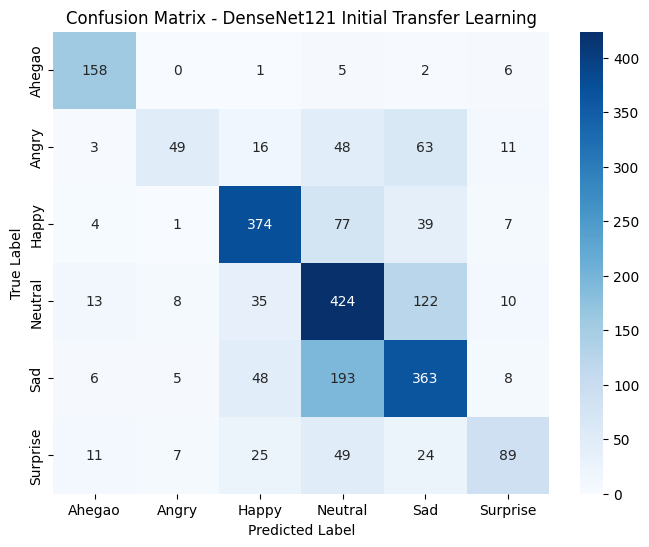

In [131]:
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_tl,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - DenseNet121 Initial Transfer Learning")
plt.show()

# Fine-Tune TL model

In [132]:
base_model.trainable = True

**Freeze the first 70% of layers and train only the last 30%:**

In [133]:
fine_tune_at = int(len(base_model.layers) * 0.7)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

**Keep Batch Normalization layers frozen. This usually makes fine-tuning more stable.**

In [134]:
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

for i, layer in enumerate(base_model.layers):
    print(i, layer.name, layer.trainable)

0 input_layer_8 False
1 zero_padding2d_4 False
2 conv1_conv False
3 conv1_bn False
4 conv1_relu False
5 zero_padding2d_5 False
6 pool1 False
7 conv2_block1_0_bn False
8 conv2_block1_0_relu False
9 conv2_block1_1_conv False
10 conv2_block1_1_bn False
11 conv2_block1_1_relu False
12 conv2_block1_2_conv False
13 conv2_block1_concat False
14 conv2_block2_0_bn False
15 conv2_block2_0_relu False
16 conv2_block2_1_conv False
17 conv2_block2_1_bn False
18 conv2_block2_1_relu False
19 conv2_block2_2_conv False
20 conv2_block2_concat False
21 conv2_block3_0_bn False
22 conv2_block3_0_relu False
23 conv2_block3_1_conv False
24 conv2_block3_1_bn False
25 conv2_block3_1_relu False
26 conv2_block3_2_conv False
27 conv2_block3_concat False
28 conv2_block4_0_bn False
29 conv2_block4_0_relu False
30 conv2_block4_1_conv False
31 conv2_block4_1_bn False
32 conv2_block4_1_relu False
33 conv2_block4_2_conv False
34 conv2_block4_concat False
35 conv2_block5_0_bn False
36 conv2_block5_0_relu False
37 conv2_b

# Recompile with a Lower Learning Rate

In [135]:
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Resetting the Call Backs

In [136]:
early_stopping_tl_fine = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr_tl_fine = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# Traning the Fine Tunned Model

In [137]:
history_fine = tl_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=25,
    callbacks=[early_stopping_tl_fine, reduce_lr_tl_fine]
)

Epoch 1/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.6476 - loss: 0.8909 - val_accuracy: 0.6548 - val_loss: 0.8717 - learning_rate: 1.0000e-05
Epoch 2/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.6658 - loss: 0.8509 - val_accuracy: 0.6608 - val_loss: 0.8390 - learning_rate: 1.0000e-05
Epoch 3/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.6736 - loss: 0.8150 - val_accuracy: 0.6707 - val_loss: 0.8377 - learning_rate: 1.0000e-05
Epoch 4/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.6882 - loss: 0.7928 - val_accuracy: 0.6814 - val_loss: 0.7835 - learning_rate: 1.0000e-05
Epoch 5/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.6961 - loss: 0.7708 - val_accuracy: 0.6771 - val_loss: 0.7984 - learning_rate: 1.0000e-05
Epoch 6/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.7048 - loss: 0.7438 - val_accuracy: 0.7050 - val_loss: 0.7455 - learning_rate: 1.0000e-05
Epoch 7/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/ste

# Training Curves for Tunned TF model

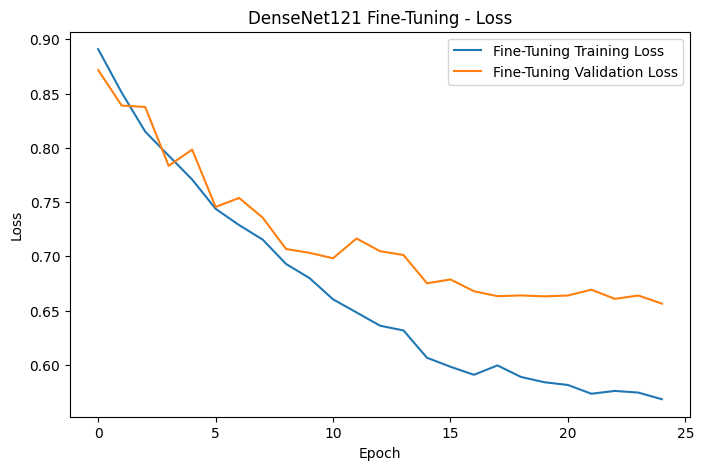

In [138]:
plt.figure(figsize=(8, 5))
plt.plot(history_fine.history["loss"], label="Fine-Tuning Training Loss")
plt.plot(history_fine.history["val_loss"], label="Fine-Tuning Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet121 Fine-Tuning - Loss")
plt.legend()
plt.show()

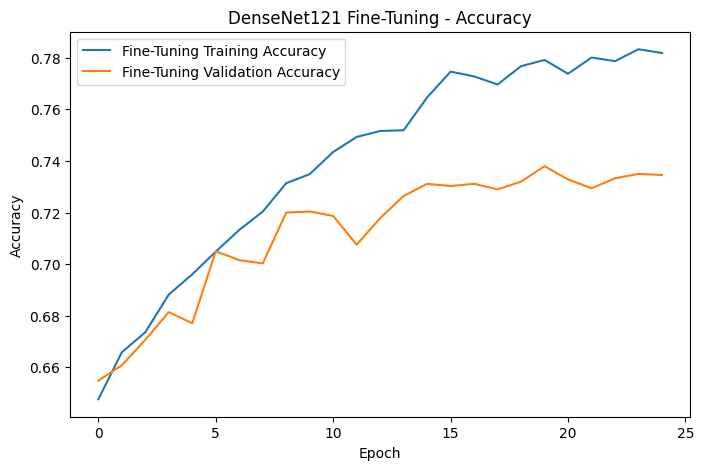

In [139]:
plt.figure(figsize=(8, 5))
plt.plot(history_fine.history["accuracy"], label="Fine-Tuning Training Accuracy")
plt.plot(history_fine.history["val_accuracy"], label="Fine-Tuning Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DenseNet121 Fine-Tuning - Accuracy")
plt.legend()
plt.show()

# Evaluate Fine-Tuned Model

In [140]:
test_loss_tl_fine, test_accuracy_tl_fine = tl_model.evaluate(test_ds_tl)

print(f"Fine-Tuned Transfer Learning Test Loss: {test_loss_tl_fine:.4f}")
print(f"Fine-Tuned Transfer Learning Test Accuracy: {test_accuracy_tl_fine:.4f}")

72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7335 - loss: 0.6712
Fine-Tuned Transfer Learning Test Loss: 0.6712
Fine-Tuned Transfer Learning Test Accuracy: 0.7335


# Classification Report After Fine-Tuning

In [141]:
y_true_tl_fine = []
y_pred_tl_fine = []

for images, labels in test_ds_tl:
    predictions = tl_model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true_tl_fine.extend(labels.numpy())
    y_pred_tl_fine.extend(predicted_classes)

y_true_tl_fine = np.array(y_true_tl_fine)
y_pred_tl_fine = np.array(y_pred_tl_fine)

In [142]:
print(classification_report(
    y_true_tl_fine,
    y_pred_tl_fine,
    target_names=class_names
))

              precision    recall  f1-score   support

      Ahegao       0.89      0.99      0.94       172
       Angry       0.77      0.46      0.58       190
       Happy       0.85      0.89      0.87       502
     Neutral       0.62      0.73      0.67       612
         Sad       0.69      0.64      0.67       623
    Surprise       0.78      0.65      0.71       205

    accuracy                           0.73      2304
   macro avg       0.77      0.73      0.74      2304
weighted avg       0.74      0.73      0.73      2304



# Confusion Matrix After Fine-Tuning

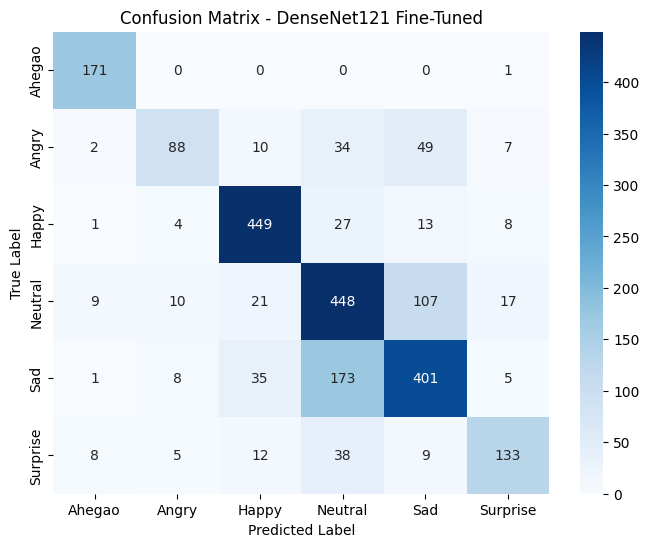

In [143]:
cm_tl_fine = confusion_matrix(y_true_tl_fine, y_pred_tl_fine)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_tl_fine,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - DenseNet121 Fine-Tuned")
plt.show()

# Compare Before and After Fine-Tuning

In [144]:
print("Initial Transfer Learning Accuracy:", test_accuracy_tl)
print("Fine-Tuned Transfer Learning Accuracy:", test_accuracy_tl_fine)

Initial Transfer Learning Accuracy: 0.6323784589767456
Fine-Tuned Transfer Learning Accuracy: 0.7335069179534912


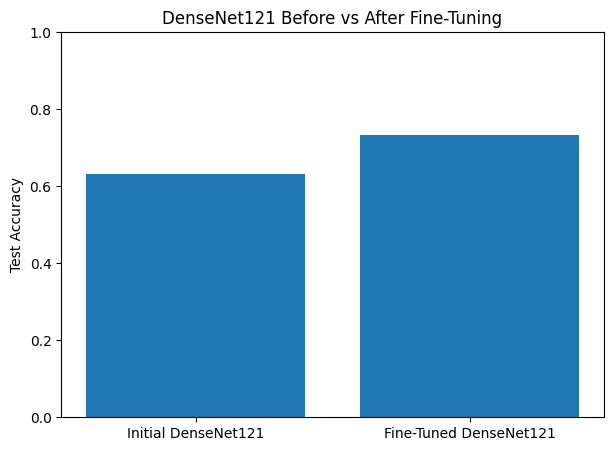

In [145]:
model_names = ["Initial DenseNet121", "Fine-Tuned DenseNet121"]
model_accuracies = [test_accuracy_tl, test_accuracy_tl_fine]

plt.figure(figsize=(7, 5))
plt.bar(model_names, model_accuracies)
plt.ylabel("Test Accuracy")
plt.title("DenseNet121 Before vs After Fine-Tuning")
plt.ylim(0, 1)
plt.show()

# Compare with Previous CNN Models

In [146]:
test_accuracy          # Simple CNN
test_accuracy_safe     # Tuned CNN
test_accuracy_tl_fine  # DenseNet121 fine-tuned model

0.7335069179534912

In [147]:
print("Simple CNN Test Accuracy:", test_accuracy)
print("Tuned CNN Test Accuracy:", test_accuracy_safe)
print("DenseNet121 Fine-Tuned Test Accuracy:", test_accuracy_tl_fine)

Simple CNN Test Accuracy: 0.6037326455116272
Tuned CNN Test Accuracy: 0.7677951455116272
DenseNet121 Fine-Tuned Test Accuracy: 0.7335069179534912


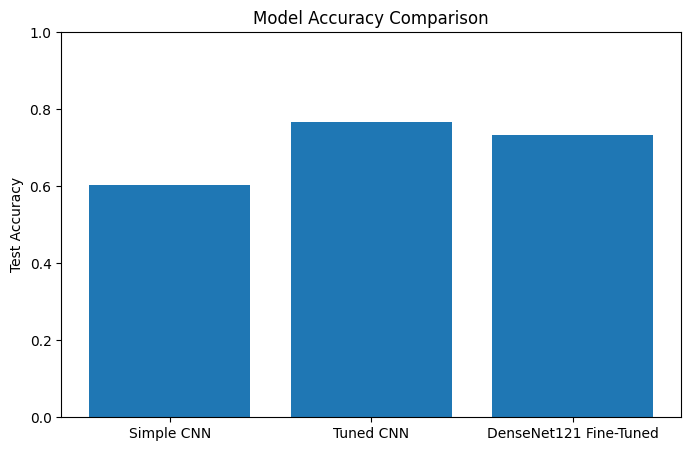

In [148]:
model_names = [
    "Simple CNN",
    "Tuned CNN",
    "DenseNet121 Fine-Tuned"
]

model_accuracies = [
    test_accuracy,
    test_accuracy_safe,
    test_accuracy_tl_fine
]

plt.figure(figsize=(8, 5))
plt.bar(model_names, model_accuracies)
plt.ylabel("Test Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

In [149]:
tl_model.save("/content/drive/MyDrive/densenet121_transfer_model.keras")